# Read the data and plot to visualize

In [ ]:
# Dataset conversion : Parquet -> CSV
import os
import pandas as pd

for file in os.listdir("../data"):
    df = pd.read_parquet(f"../data/{file}")
    csv_file_name = file.replace(".parquet", ".csv")
    df.to_csv(f"csv_data/{csv_file_name}", index=False)

In [ ]:
# returns dataframe for the provided Parquet dataset file
def lidar_data_df_func(dataset):
    lidar_data_df = pd.read_parquet(f"../data/{dataset}.parquet")
    return lidar_data_df
lidar_data_df_easy = lidar_data_df_func("lidar_cable_points_easy")
lidar_data_df_easy_labels = lidar_data_df_easy
lidar_data_df_medium = lidar_data_df_func("lidar_cable_points_medium")
lidar_data_df_medium_labels = lidar_data_df_medium
lidar_data_df_hard = lidar_data_df_func("lidar_cable_points_hard")
lidar_data_df_hard_labels = lidar_data_df_hard
lidar_data_df_extrahard = lidar_data_df_func("lidar_cable_points_extrahard")
lidar_data_df_extrahard_labels = lidar_data_df_extrahard
dataset_dic = {"easy": lidar_data_df_easy, "medium": lidar_data_df_medium, "hard": lidar_data_df_hard, "extrahard": lidar_data_df_extrahard}
for name, dataset in dataset_dic.items():
    print("\nDataset:", name)
    print(dataset.head())
    print(dataset.columns)
    print(dataset.shape)


Dataset: easy
              x          y          z
2211   6.196634 -13.157755  10.582272
2905 -10.440643  17.264460  10.926065
1411   2.977432  -3.552676  10.072814
251    5.924494 -10.974960  10.342501
794   -7.062873  12.850664  10.557997
Index(['x', 'y', 'z'], dtype='object')
(1502, 3)

Dataset: medium
             x          y          z
5117  8.927091 -17.271705   7.724551
3574 -0.514603   3.713301   6.604667
245   6.141806 -11.188338  10.438597
3258  6.998778 -10.146784   6.937106
5803 -7.537887  12.818930   7.195763
Index(['x', 'y', 'z'], dtype='object')
(2803, 3)

Dataset: hard
              x          y          z
2211   6.218581 -13.165374  10.530679
2905 -10.478510  17.248335  10.921316
1411   2.968935  -3.533002  10.008485
251    5.925292 -10.927853  10.407309
794   -7.029980  12.853360  10.579427
Index(['x', 'y', 'z'], dtype='object')
(601, 3)

Dataset: extrahard
              x          y          z
2211   6.037626 -13.231044  10.527397
2905 -10.721094  17.124476  10.94

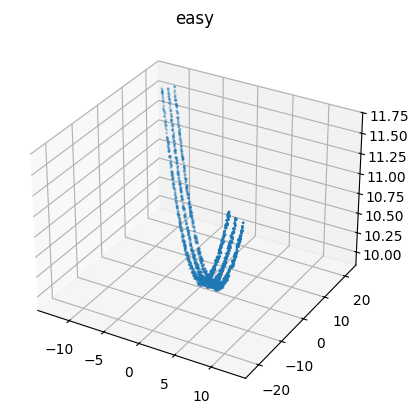

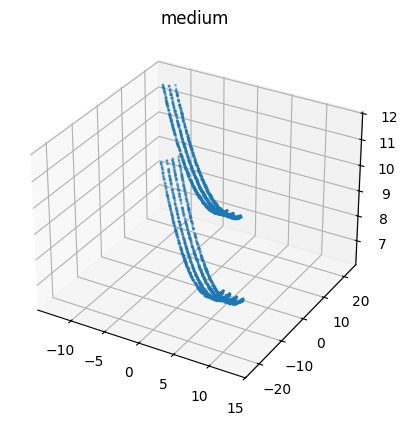

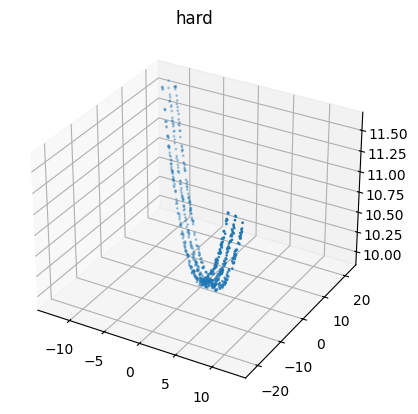

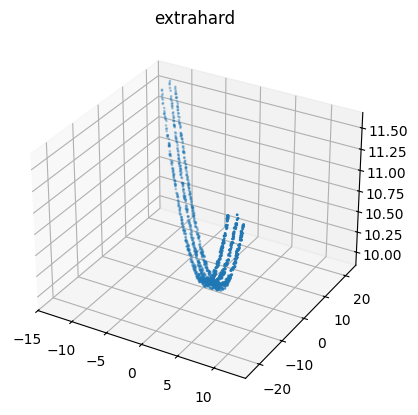

In [190]:
# looks like x, y, z are the column coordinates, check in graphical form
import matplotlib.pyplot as plt

for k,dataset in dataset_dic.items():
    # print(f"Plot for {k}")
    blank_canvas = plt.figure().add_subplot(111, projection="3d")
    blank_canvas.scatter(dataset["x"], dataset["y"], dataset["z"], s=1)
    blank_canvas.set_title(f"{k}")
    plt.savefig(f"images/vis_{k}.png")

In [191]:
# numpy array
coordinates = lidar_data_df_easy[["x", "y", "z"]].values
print(coordinates)

[[  6.19663435 -13.15775512  10.58227233]
 [-10.44064287  17.26446014  10.92606471]
 [  2.97743169  -3.55267568  10.0728142 ]
 ...
 [ -9.74456296  19.54896042  11.2729797 ]
 [ -2.06073546   5.73005863  10.09060331]
 [ 11.12628854 -18.49790267  11.07095826]]


# Note: 
Data loaded and explored to understand the details of the dataset. Visulaization of data is performed.

# DBScan Clustering

## Easy - DBScan clustering

In [ ]:
# clustering and no. of clusters 
from sklearn.cluster import DBSCAN
#eps_list = [0.5, 1, 1.5, 2.5, 3, 3.5, 4, 4.5, 5, 0.6, 0.7, 0.8, 0.9]
eps_list = [0.65, 0.7, 0.75, 0.8]
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.65, Unique clusters: {0, 1, 2}
For eps = 0.7, Unique clusters: {0, 1, 2}
For eps = 0.75, Unique clusters: {0, 1, 2}
For eps = 0.8, Unique clusters: {0}


In [21]:
# clustering and no. of clusters
from sklearn.cluster import DBSCAN
#eps_list = [0.5, 1, 1.5, 2.5, 3, 3.5, 4, 4.5, 5, 0.6, 0.7, 0.8, 0.9]
eps_list = [0.76] #0.65, 0.7, 0.75, 0.75, 0.8
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.76, Unique clusters: {0, 1, 2}


For easy graph - eps value can be between 0.65 and 0.76

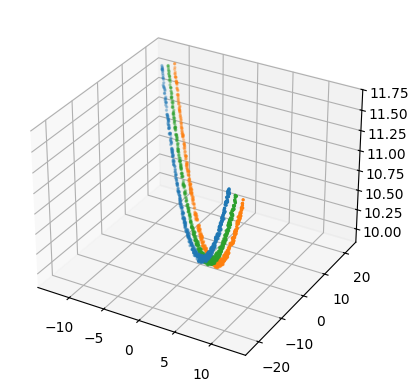

In [22]:
# cluster list visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = coordinates[labels == cluster_id]
    blank_canvas.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], s=2)
plt.savefig("images/cluster_list_visualization.png")

## Medium - DBScan Clustering

In [23]:
# numpy array
coordinates_medium = lidar_data_df_medium[["x", "y", "z"]].values
print(coordinates_medium)

[[  8.92709104 -17.27170487   7.72455081]
 [ -0.51460285   3.71330132   6.60466739]
 [  6.14180642 -11.18833806  10.43859675]
 ...
 [  3.35515603  -8.01030698  10.20106081]
 [  1.36849341  -0.65532002   9.98307589]
 [  5.46552352 -11.91274029  10.49119338]]


In [41]:
import numpy as np
def generate_list(start, end, step):
    return np.round(np.arange(start, end, step), 4).tolist()

In [28]:
# clustering and no. of clusters 
from sklearn.cluster import DBSCAN
#eps_list = [0.5, 1, 1.5, 2.5, 3, 3.5, 4, 4.5, 5]
eps_list = generate_list(0.7, 0.8, 0.005)
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates_medium)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.7, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
For eps = 0.7, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
For eps = 0.71, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
For eps = 0.72, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.72, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.72, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.73, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.74, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.74, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.74, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.75, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
For eps = 0.76, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8}
For eps = 0.76, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8}
For eps = 0.76, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8}
For eps = 0.77, Unique clusters: {0, 1, 2, 3, 4, 5, 6}
For eps = 0.78, Unique clusters: {0,

In [31]:
# clustering and no. of clusters
from sklearn.cluster import DBSCAN
eps_list = [0.74]
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates_medium)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.74, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


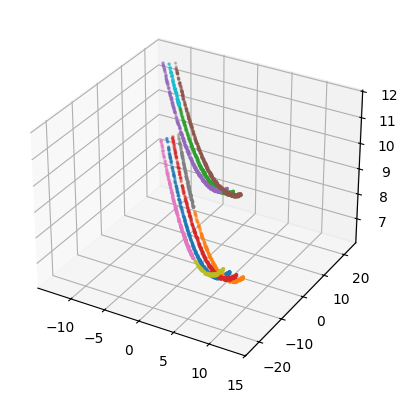

In [32]:
# cluster list visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = coordinates_medium[labels == cluster_id]
    blank_canvas.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], s=2)
plt.savefig("images/cluster_list_visualization.png")

## Hard - DBScan Clustering

In [33]:
# numpy array
coordinates_hard = lidar_data_df_hard[["x", "y", "z"]].values
print(coordinates_medium)

[[  8.92709104 -17.27170487   7.72455081]
 [ -0.51460285   3.71330132   6.60466739]
 [  6.14180642 -11.18833806  10.43859675]
 ...
 [  3.35515603  -8.01030698  10.20106081]
 [  1.36849341  -0.65532002   9.98307589]
 [  5.46552352 -11.91274029  10.49119338]]


In [44]:
# clustering and no. of clusters 
from sklearn.cluster import DBSCAN
#eps_list = [0.5, 1, 1.5, 2.5, 3, 3.5, 4, 4.5, 5]
#eps_list = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
eps_list = generate_list(0.75, 1, 0.005)
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates_hard)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.75, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, -1}
For eps = 0.755, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, -1}
For eps = 0.76, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, -1}
For eps = 0.765, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, -1}
For eps = 0.77, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, -1}
For eps = 0.775, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, -1}
For eps = 0.78, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2

In [42]:
eps_list = generate_list(0.75, 0.85, 0.005)
eps_list

[0.75,
 0.755,
 0.76,
 0.765,
 0.77,
 0.775,
 0.78,
 0.785,
 0.79,
 0.795,
 0.8,
 0.805,
 0.81,
 0.815,
 0.82,
 0.825,
 0.83,
 0.835,
 0.84,
 0.845]

In [51]:
# clustering and no. of clusters
from sklearn.cluster import DBSCAN
eps_list = [0.77]
for eps_value in eps_list:
    db_scan = DBSCAN(eps=eps_value, min_samples=5)
    labels = db_scan.fit_predict(coordinates_hard)
    print(f"For eps = {eps_value}, Unique clusters: {set(labels)}")

For eps = 0.77, Unique clusters: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, -1}


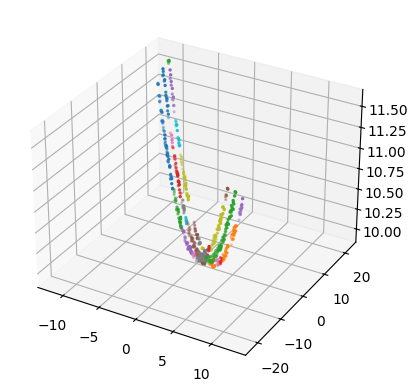

In [52]:
# cluster list visualization
blank_canvas = plt.figure().add_subplot(111, projection="3d")
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = coordinates_hard[labels == cluster_id]
    blank_canvas.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], s=2)
plt.savefig("images/cluster_list_visualization.png")

# Note:
Tried eps values in the range (0–1) with step sizes of 0.01 and 0.001.
- Based on stable cluster point values, plotted the graph.
- worked well for the easy dataset.
- But for medium and hard datasets, even when eps values produced stable cluster counts, the visualized clusters were not accurate (overlap issues).

# Note:
It looks like the cluster is a big vague having the same line with multiple color, so whatever done might be wrong.  
Is it the angle at which drone captured data? probably overlapping wires?  
Makes sense to be honest, the wires are also no good U shaped, change the angle we view?  

Question: for a 3d data of cable wires if we want to view it in 2d what algo should be used in python scikit learn package?


# PCA - Clustering

In [230]:
n_samples = lidar_data_df_extrahard.shape[0]
n_feature = lidar_data_df_extrahard.shape[1]
n_componets = min(n_samples, n_feature)
from sklearn.decomposition import PCA
points = lidar_data_df_extrahard[["x","y","z"]].values

pca = PCA(n_components=n_componets).fit(points)
projected = pca.transform(points)

I think the PCA is having 3d vector which shows along different axes?

PC 1 removed — unique labels: {0, 1, 2}


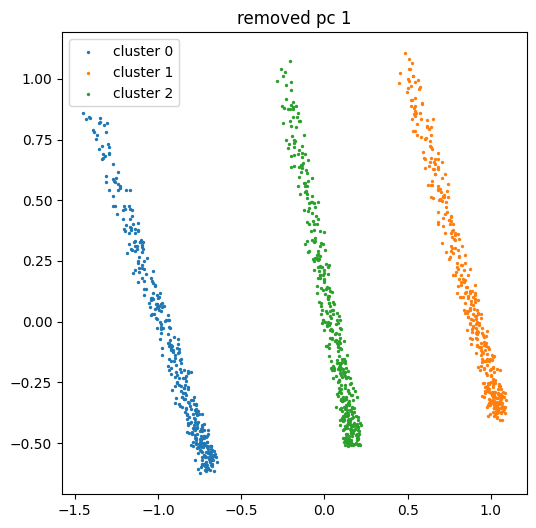

PC 2 removed — unique labels: {0}


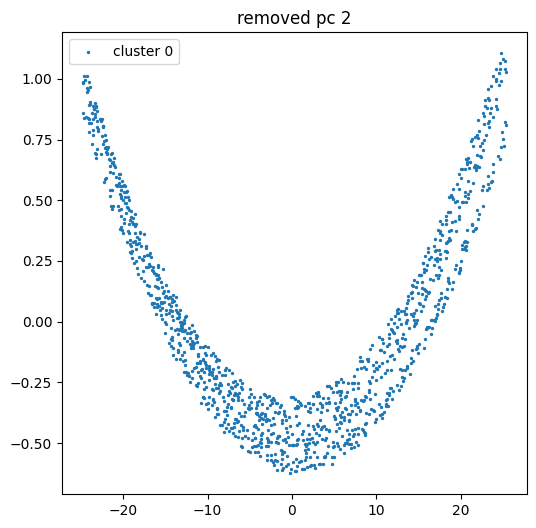

PC 3 removed — unique labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, -1}


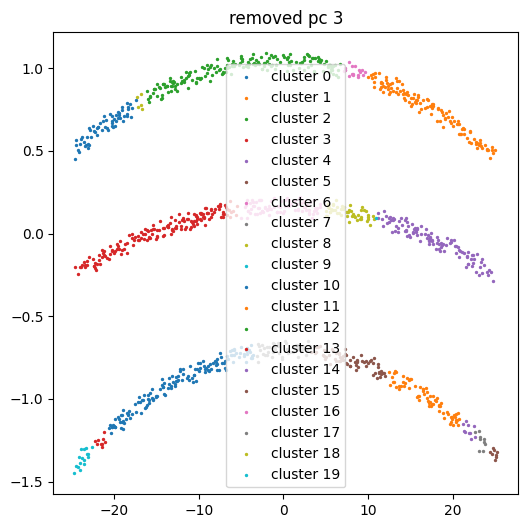

In [231]:
for i in range(0, 3):
    reduced = np.delete(projected, i, axis=1)
    labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(reduced)
    
    print(f"PC {i+1} removed — unique labels: {set(labels)}")  # debug line
    
    plt.figure(figsize=(6, 6))
    for cluster_id in set(labels):
        if cluster_id == -1:
            continue
        cluster_points = reduced[labels == cluster_id]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                    s=2, label=f"cluster {cluster_id}")
    
    plt.title(f"removed pc {i+1}")
    plt.legend()
    plt.savefig(f"images/cluster_removed_pc{i+1}.png")  # save separately!
    plt.show()

I can find teh clear separable clusters from plot 1, but in real pipeline what can i do to find it automatically? we dont need to look into the graph manually every time isnt it

In [195]:
(pca.explained_variance_ratio_)

array([0.9966264 , 0.00237137, 0.00100223])

In [232]:
remove_axis = np.argmax((pca.explained_variance_ratio_))
actual_reduced = np.delete(projected, remove_axis, axis=1)
actual_reduced

array([[-0.92594153, -0.07727861],
       [-1.13783883,  0.33298198],
       [ 1.0097382 , -0.33237691],
       ...,
       [ 0.11427432, -0.20723218],
       [ 0.08809412, -0.24099787],
       [ 0.15410881, -0.23431943]])

First lets assign the clusters to the points

(1201, 4)
              x          y          z  labels
2211   6.037626 -13.231044  10.527397       0
2905 -10.721094  17.124476  10.943132       0
1411   2.893274  -3.527691  10.035204       1
251    5.870610 -10.909318  10.419144       2
794   -7.155748  12.846815  10.556583       2


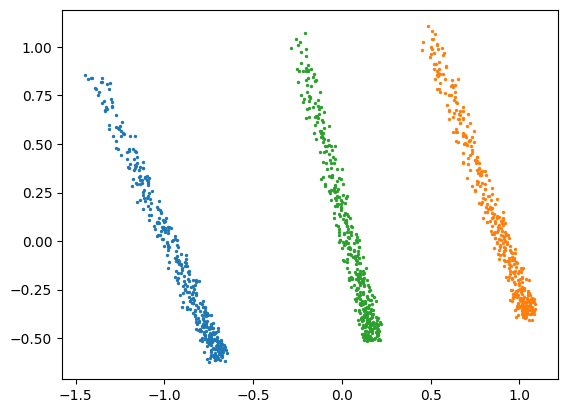

In [233]:
# from scipy.optimize import curver_fit

labels = DBSCAN(eps = 0.5, min_samples = 5).fit_predict(actual_reduced)
# plt.figure(figsize=(6,6))
for cluster_id in set(labels):
    if cluster_id == -1:
        continue
    cluster_points = actual_reduced[labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=2, label = f"cluster {cluster_id}")
    # plt.title(f"removed pc {i+1}")
    # pts = points[labels == cluster_id]
plt.savefig("images/cluster_list_visualization.png")
# print(len(labels))
# print(lidar_data_df_easy_labels.head())
lidar_data_df_extrahard_labels["labels"] = labels
print(lidar_data_df_extrahard_labels.shape)
print(lidar_data_df_extrahard_labels.head())

Actually we need to find a brute force method for dbscan value for epislon. But it is working fine for now for default values, eps=0.5 and min_samples=5.

# Note:
Applied PCA on LiDAR data points. Different principal components were removed and tested  the clustering output. Seems when PC1 is removed, clustering is perfect, since we cannot do it manually everytime - found that removing the highest variance component (using explained variance ratio)gives better clustering results.

# 3D->2D - catanary curve

Which 2D?

              x          y          z
2211   6.218581 -13.165374  10.530679
2905 -10.478510  17.248335  10.921316
1411   2.968935  -3.533002  10.008485
251    5.925292 -10.927853  10.407309
794   -7.029980  12.853360  10.579427
(601, 3)
              x          y          z
2211   6.218581 -13.165374  10.530679
2905 -10.478510  17.248335  10.921316
1411   2.968935  -3.533002  10.008485
251    5.925292 -10.927853  10.407309
794   -7.029980  12.853360  10.579427

 2D Array. Removed axis = 0
[[-13.16537393  10.5306789 ]
 [ 17.24833505  10.92131613]
 [ -3.53300205  10.00848487]
 [-10.92785291  10.40730912]
 [ 12.85335959  10.57942657]]

 2D Array. Removed axis = 1
[[  6.21858054  10.5306789 ]
 [-10.47851003  10.92131613]
 [  2.96893461  10.00848487]
 [  5.92529154  10.40730912]
 [ -7.02998014  10.57942657]]

 2D Array. Removed axis = 2
[[  6.21858054 -13.16537393]
 [-10.47851003  17.24833505]
 [  2.96893461  -3.53300205]
 [  5.92529154 -10.92785291]
 [ -7.02998014  12.85335959]]


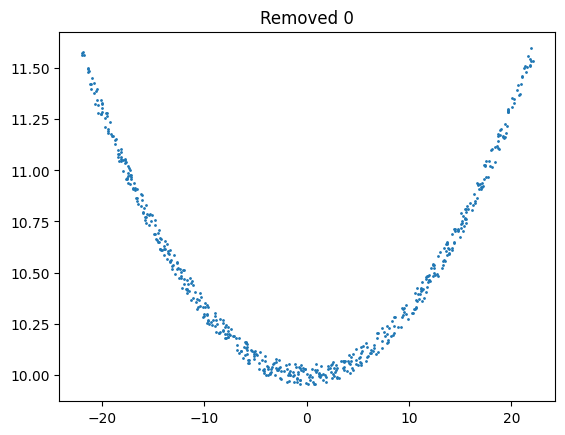

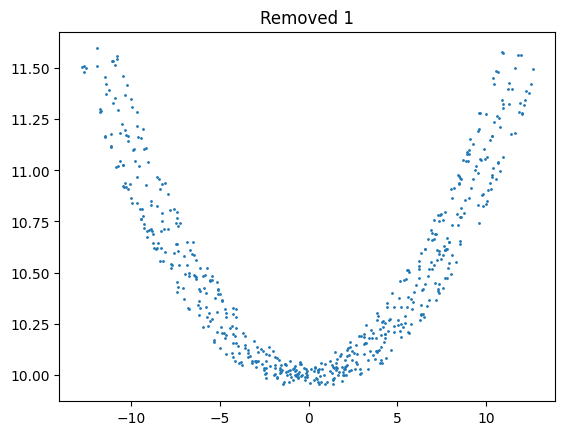

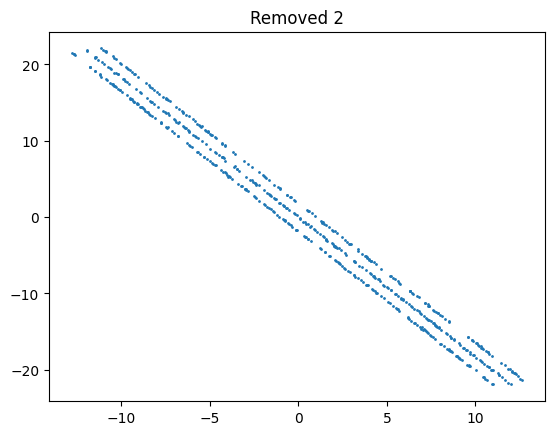

In [ ]:
# import matplotlib.pyplot as plt
# lidar_data_df = pd.read_parquet("../data/lidar_cable_points_hard.parquet")
# print(lidar_data_df.head())
# # print(dataset.columns)
# print(lidar_data_df.shape)
# lidar_data_array = lidar_data_df[["x","y","z"]].values
# print(lidar_data_df[:5])
# for iter_axis in [0 ,1, 2]:
#     array_2d = np.delete(lidar_data_array, iter_axis, axis=1)
#     print("\n 2D Array. Removed axis =", iter_axis)
#     print(array_2d[:5])
#     blank_canvas = plt.figure().add_subplot(111)
#     blank_canvas.scatter(array_2d[:, 0], array_2d[:, 1], s=1)
#     blank_canvas.set_title(f"Removed {iter_axis}")

Difficult to form a curve in all three cases. So, may be - plot each wire seperatly in three different views?

(387, 4)
[[  6.03762622 -13.23104425  10.52739708   0.        ]
 [-10.72109418  17.12447568  10.94313198   0.        ]
 [ -2.46610122   2.72159783  10.01256244   0.        ]
 [  0.76363961  -3.17188457  10.05866785   0.        ]
 [  2.19634168  -5.84766397  10.06201549   0.        ]]

 2D Array. Removed axis = 0
[[-13.23104425  10.52739708   0.        ]
 [ 17.12447568  10.94313198   0.        ]
 [  2.72159783  10.01256244   0.        ]
 [ -3.17188457  10.05866785   0.        ]
 [ -5.84766397  10.06201549   0.        ]]

 2D Array. Removed axis = 1
[[  6.03762622  10.52739708   0.        ]
 [-10.72109418  10.94313198   0.        ]
 [ -2.46610122  10.01256244   0.        ]
 [  0.76363961  10.05866785   0.        ]
 [  2.19634168  10.06201549   0.        ]]

 2D Array. Removed axis = 2
[[  6.03762622 -13.23104425   0.        ]
 [-10.72109418  17.12447568   0.        ]
 [ -2.46610122   2.72159783   0.        ]
 [  0.76363961  -3.17188457   0.        ]
 [  2.19634168  -5.84766397   0.      

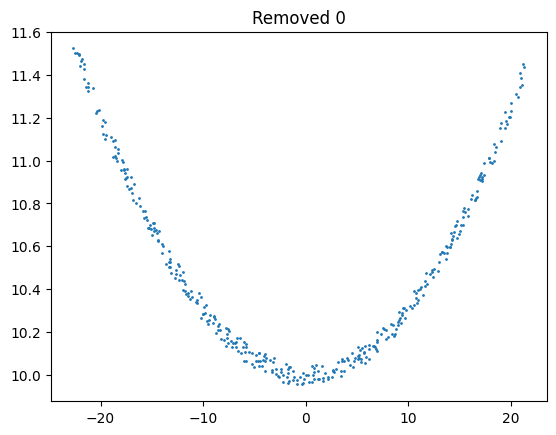

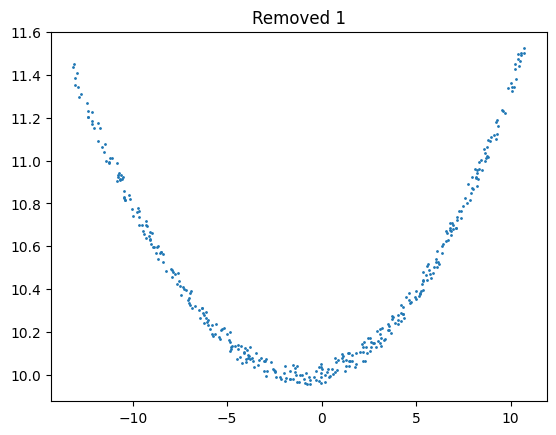

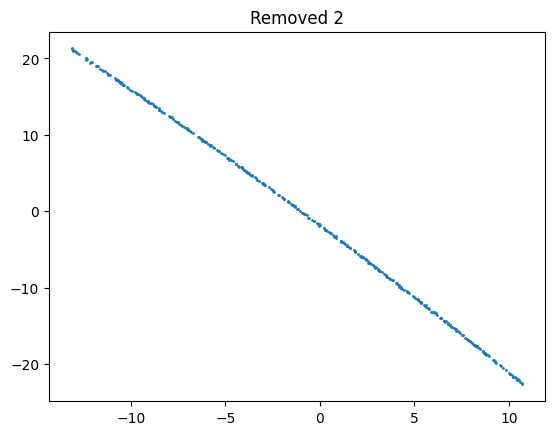

In [234]:
lidar_data_df_labels = lidar_data_df_extrahard_labels[["x","y","z","labels"]].values
# print(lidar_data_df_labels[:5])
cluster_0 = lidar_data_df_labels[labels == 0]
print(cluster_0.shape)
print(cluster_0[:5])
for iter_axis in [0 ,1, 2]:
    array_2d_labels = np.delete(cluster_0, iter_axis, axis=1)
    print("\n 2D Array. Removed axis =", iter_axis)
    print(array_2d_labels[:5])
    blank_canvas = plt.figure().add_subplot(111)
    blank_canvas.scatter(array_2d_labels[:, 0], array_2d_labels[:, 1], s=1)
    blank_canvas.set_title(f"Removed {iter_axis}")

(387, 4)
[[  6.03762622 -13.23104425  10.52739708   0.        ]
 [-10.72109418  17.12447568  10.94313198   0.        ]
 [ -2.46610122   2.72159783  10.01256244   0.        ]
 [  0.76363961  -3.17188457  10.05866785   0.        ]
 [  2.19634168  -5.84766397  10.06201549   0.        ]]

 2D Array. Removed axis = 0
[[-13.23104425  10.52739708   0.        ]
 [ 17.12447568  10.94313198   0.        ]
 [  2.72159783  10.01256244   0.        ]
 [ -3.17188457  10.05866785   0.        ]
 [ -5.84766397  10.06201549   0.        ]]

 2D Array. Removed axis = 1
[[  6.03762622  10.52739708   0.        ]
 [-10.72109418  10.94313198   0.        ]
 [ -2.46610122  10.01256244   0.        ]
 [  0.76363961  10.05866785   0.        ]
 [  2.19634168  10.06201549   0.        ]]

 2D Array. Removed axis = 2
[[  6.03762622 -13.23104425   0.        ]
 [-10.72109418  17.12447568   0.        ]
 [ -2.46610122   2.72159783   0.        ]
 [  0.76363961  -3.17188457   0.        ]
 [  2.19634168  -5.84766397   0.      

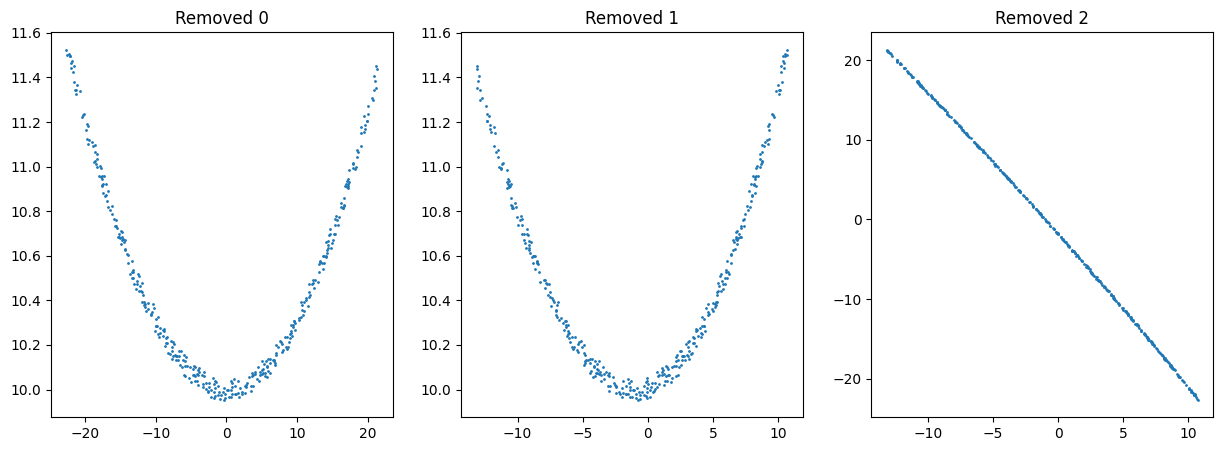

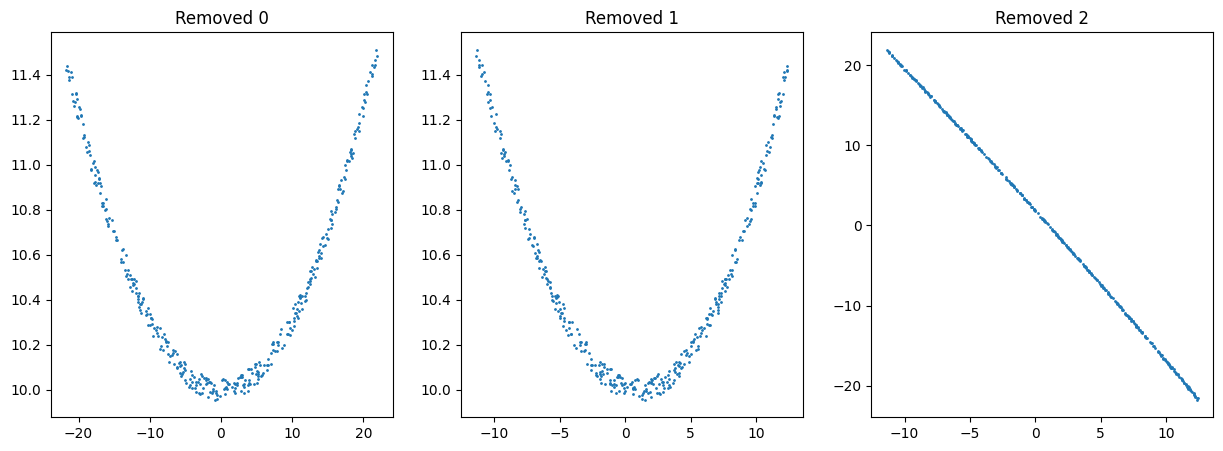

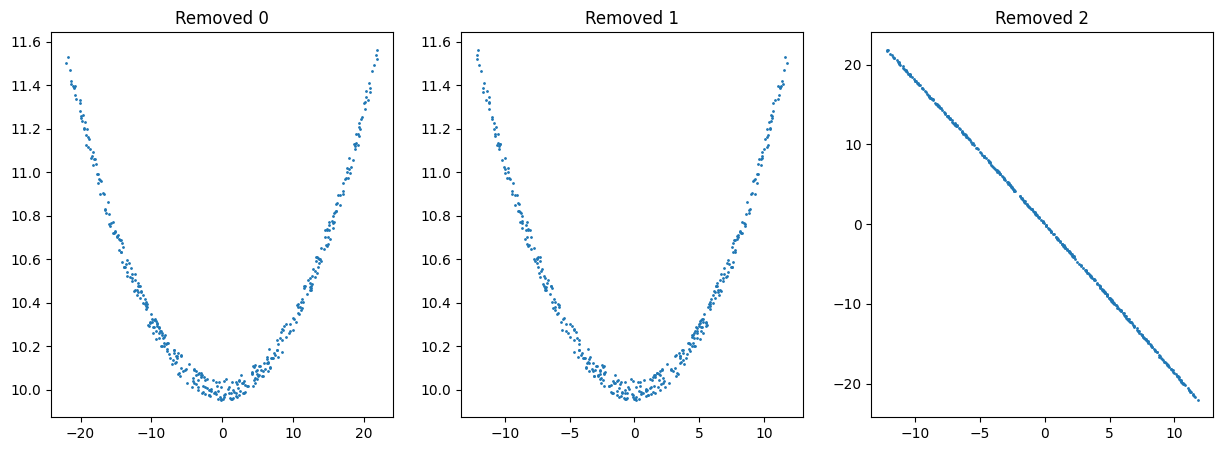

In [235]:
lidar_data_df_labels = lidar_data_df_extrahard_labels[["x","y","z","labels"]].values
# print(lidar_data_df_labels[:5])
for cluster_number in [0, 1, 2]:
    cluster_0 = lidar_data_df_labels[labels == cluster_number]
    print(cluster_0.shape)
    print(cluster_0[:5])
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for iter_axis in [0 ,1, 2]:
        array_2d_labels = np.delete(cluster_0, iter_axis, axis=1)
        print("\n 2D Array. Removed axis =", iter_axis)
        print(array_2d_labels[:5])
        axes[iter_axis].scatter(array_2d_labels[:, 0], array_2d_labels[:, 1], s=1)
        axes[iter_axis].set_title(f"Removed {iter_axis}")

Plotted the clusters sepeartly by removing each column individually. The three images represent one wire cluster projected onto the YZ, XZ and xy planes by remving each column values repectively.
Can we do the curve fitting on these now?

Curve best fit for the first cluster

In [ ]:
lidar_data_df_labels = lidar_data_df_hard_labels[["x","y","z","labels"]].values
mini_lidar_data_cluster_0 = lidar_data_df_labels[labels == 0]
mini_lidar_data_cluster_0_YZ = np.delete(mini_lidar_data_cluster_0, 0, axis=1)
print(mini_lidar_data_cluster_0_YZ)

[[-13.16537393  10.5306789    0.        ]
 [ 17.24833505  10.92131613   0.        ]
 [  2.71657384  10.03126313   0.        ]
 [ -3.14326355  10.05669888   0.        ]
 [ -5.91000599  10.13183264   0.        ]
 [-18.32280942  11.0450317    0.        ]
 [ 11.71117658  10.40257654   0.        ]
 [  4.32292311  10.08896812   0.        ]
 [-20.9907263   11.45178083   0.        ]
 [ 14.40667841  10.64337991   0.        ]
 [ 14.7548282   10.70949515   0.        ]
 [ -8.83965945  10.26713049   0.        ]
 [ -7.9504102   10.17925661   0.        ]
 [-11.22529177  10.45714011   0.        ]
 [ 13.75759109  10.64465897   0.        ]
 [  8.55611722  10.23804929   0.        ]
 [  0.66725119   9.96237391   0.        ]
 [  5.04044461  10.04603324   0.        ]
 [-15.38896197  10.78012034   0.        ]
 [ 11.21803167  10.42621003   0.        ]
 [  8.31230874  10.26510671   0.        ]
 [ -2.61841348   9.98564215   0.        ]
 [-14.19176706  10.66298526   0.        ]
 [ 15.54894917  10.81060207   0.  

In [241]:
# Catanary curve equation
import numpy as np
def curve_equation(x, x0, y0, c):
    return y0 + c * (np.cosh((x - x0) / c) - 1)


In [214]:
from scipy.optimize import curve_fit
y_data = mini_lidar_data_cluster_0_YZ[:, 0]
z_data= mini_lidar_data_cluster_0_YZ[:, 1]
# initial_assumption_values = [np.mean(x_data), np.min(y_data), 100]
params, covariance = curve_fit(curve_equation, y_data, z_data, p0 = None)
x0, y0, c = params
print("x0 = ", float(x0))
print("y0 = ", float(y0))
print("c = ", float(c))

x0 =  -0.021298198899314644
y0 =  10.002239901946906
c =  154.46529844185716


In [224]:
sort_idx = np.argsort(y_data)
y_data_sorted = y_data[sort_idx]
z_data_sorted = z_data[sort_idx]
z_fit_new = curve_equation(y_data_sorted,x0,y0,c)


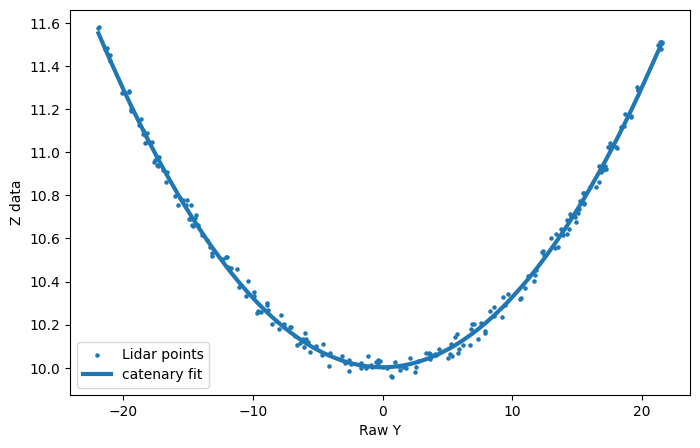

In [228]:
plt.figure(figsize=(8,5))
plt.scatter(y_data, z_data, s=5, label = "Lidar points")
plt.plot(y_data_sorted,z_fit_new,linewidth=3, label = "catenary fit")
plt.xlabel("Raw Y")
plt.ylabel("Z data")
plt.legend()
plt.show()

This works but we will have to manually give give axis values as static, so better go for "Along the wire axis values" as Xdata and Height value as YData for the curve fit.

In [240]:
lidar_data_df_labels = lidar_data_df_extrahard_labels[["x","y","z","labels"]].values
print(lidar_data_df_labels.shape)
mini_lidar_data_cluster_0 = lidar_data_df_labels[labels == 0]
print(mini_lidar_data_cluster_0.shape)
print(mini_lidar_data_cluster_0)

(1201, 4)
(387, 4)
[[  6.03762622 -13.23104425  10.52739708   0.        ]
 [-10.72109418  17.12447568  10.94313198   0.        ]
 [ -2.46610122   2.72159783  10.01256244   0.        ]
 ...
 [-11.62159258  18.5792924   11.06533074   0.        ]
 [-12.40011492  20.00113631  11.27062713   0.        ]
 [  8.50086687 -18.0142531   10.95547713   0.        ]]


## final catenary curve

In [252]:
#get number of wires
num_wires = lidar_data_df_extrahard_labels['labels'].nunique()

In [260]:
#get number of wires
num_wires = lidar_data_df_extrahard_labels['labels'].nunique()
wire_data = {}
# loop through each wire and get the caternary curve values
cater_points_dict = {}
for wire in range(num_wires):
    min_df = lidar_data_df_extrahard_labels[lidar_data_df_extrahard_labels['labels']==wire]
    min_df_pts = min_df[["x","y","z"]].values
    wire_name = f"wire_{wire}"
    pca_wire = PCA(n_components=min(n_samples, n_feature)).fit(min_df_pts)
    pca_wire_projected = pca_wire.transform(min_df_pts)
    x_local = pca_wire_projected[:,0]
    z = min_df_pts[:,2]
    wire_data[wire_name] = {'x_local':x_local, 'z':z}
    popt_wire, _ = curve_fit(curve_equation,x_local, z, p0=None)
    
    x0 = popt_wire[0]
    y0 = popt_wire[1]
    c = popt_wire[2]
    cater_points_dict[wire_name] = {"x0":x0,"y0":y0,"c":c}


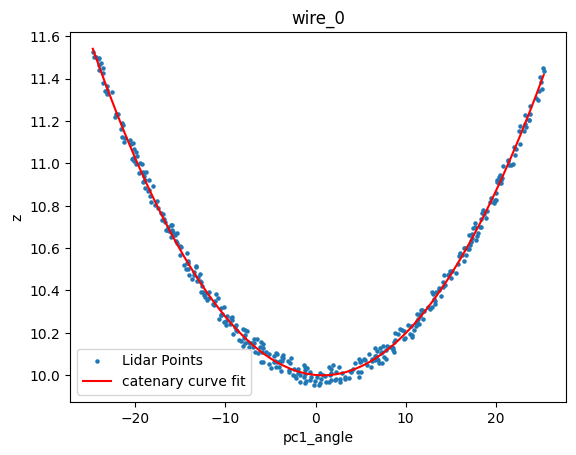

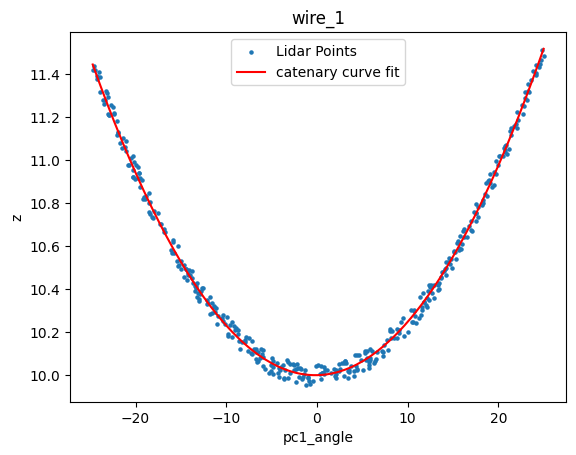

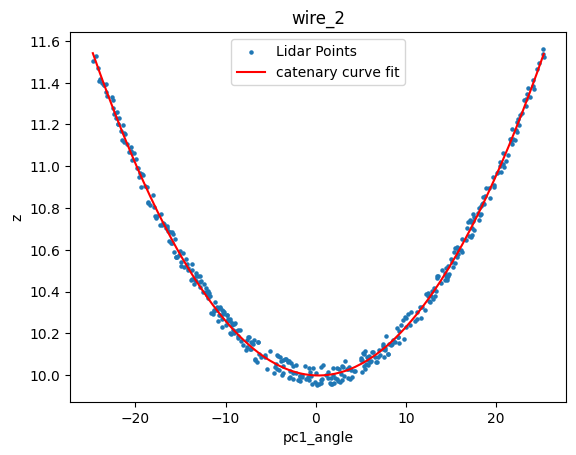

In [262]:
# plotting
for wire_name in cater_points_dict:
    params = cater_points_dict[wire_name]
    x_local = wire_data[wire_name]['x_local']
    z = wire_data[wire_name]['z']

    sort_idx = np.argsort(x_local)
    x_line_value = x_local[sort_idx]
    z_data_sorted_value = z[sort_idx]
    z_line_value = curve_equation(x_line_value,params["x0"],params["y0"],params["c"])

    # x_line = np.linspace(x_local.min(),x_local.max(), 500)
    # z_line = curve_equation(x_line, params["x0"],params["y0"],params["c"])

    plt.figure()
    plt.scatter(x_local, z, s=5, label = "Lidar Points")
    plt.plot(x_line_value, z_line_value, color = "red", label = "catenary curve fit")
    plt.title(wire_name)
    plt.xlabel("pc1_angle")
    plt.ylabel("z")
    plt.legend()
    plt.show()


# Note:
Initially, projected full dataset into different 2D planes by removing one axis at a time, but it was difficult to clearly observe a curve structure. So, tried for each cluster the same way and it worked for YZ, ZX views. Choosing manually the axes is not reliable so its better to use "along the wire" and "z" vlaues as X and Y axis for curve fitting and modelling the wire shape.
Did the same and plotted against the original LiDAR points to vallidate the wire shape.